### Retina Blood Vessels Segmentation using U-Net

#### Import Libraries

In [1]:
import os
from tqdm import tqdm
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

##### Check if GPU is available

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#### Dataset for Retina Blood Vessels Segmentation

In [3]:
# link to the Dataset
# https://www.kaggle.com/datasets/abdallahwagih/retina-blood-vessel

In [4]:
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, target_transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform                
        self.target_transform = target_transform 
        self.image_files = os.listdir(image_dir)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            mask = self.target_transform(mask)

        return image, mask


#### Transform the Images and Masks to Tensors

In [5]:
image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

mask_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float())
])

#### Local paths for the Dataset

In [6]:
train_dataset = SegmentationDataset(
    image_dir = './data/train/augmented/image',
    mask_dir = './data/train/augmented/mask',
    transform=image_transform,
    target_transform=mask_transform
)

val_dataset = SegmentationDataset(
    image_dir = './data/val/image',
    mask_dir = './data/val/mask',
    transform=image_transform,
    target_transform=mask_transform
)

test_dataset = SegmentationDataset(
    image_dir = './data/test/image',
    mask_dir = './data/test/mask',
    transform=image_transform,
    target_transform=mask_transform
)

#### Load the Dataset

In [7]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=10, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

### U-Net Model

U-Net is a type of a neural network which is mainly used for image segmentation i.e dividing the objects in an image into different parts for example separating a tumor from healthy tissue in a medical scan. The name “U-Net” comes from the shape of its architecture because the whole architecture resembles the shape of letter "U". It is widely used in medical imaging because it performs well even with a small amount of labeled data.

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [9]:
def dice_coef(preds, targets, smooth=1.0):
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum()
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

In [10]:
# Input Image:        3 channels (RGB)

# Down Block 1 →      64 features
# Down Block 2 →      128 features
# Down Block 3 →      256 features
# Down Block 4 →      512 features

# Bottleneck   →      1024 features (512 * 2)

# Up Block 1   ←      512 features
# Up Block 2   ←      256 features
# Up Block 3   ←      128 features
# Up Block 4   ←      64 features

# Final Output →      1 channel (mask)
    
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.down_path = nn.ModuleList()
        self.up_path = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # DownSample Part
        for feature in features:
            self.down_path.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # UpSample Part
        for feature in reversed(features):
            self.up_path.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.up_path.append(DoubleConv(feature*2, feature))

        # BottleNeck Part
        self.bottle_neck = DoubleConv(features[-1], features[-1]*2)

        # Final Conv Layer 
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.down_path:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottle_neck(x)
        skip_connections = skip_connections[::-1] # inverse the skip connections for concat

        for idx in range(0, len(self.up_path), 2):

            # for the upsample part as up_path[0]..[2]..gives upsample part from corresponding [0//2]..[2//2] block
            x = self.up_path[idx](x)
            skip_connection = skip_connections[idx//2]

            if x.shape != skip_connection.shape:
                x = torch.nn.functional.interpolate(x, size=skip_connection.shape[2:])

            # concat the x from upsample op with skip connection as such that C+C=2C such that in_channels = 2*feature
            x = torch.cat((x, skip_connection), dim=1)

            # does the doub_conv as the pair with [1]..[3] gives conv part in the up_path module for [1//2]..[3//2] block
            x = self.up_path[idx+1](x)

        return torch.sigmoid(self.final_conv(x))

In [11]:
num_epochs = 10
learning_rate = 0.001
target_dice = 0.75

In [12]:
train_losses = []
val_losses = []
train_dices = []
val_dices = []

In [13]:
model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [ ]:
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_dice = 0

    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch [{epoch+1}/{num_epochs}]")

    for batch_idx, (image, mask) in loop:
        image = image.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()
        output = model(image)

        loss = criterion(output, mask)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = output
        pred = (pred > 0.5).float()
        dice = dice_coef(pred, mask)
        train_dice += dice.item()

        loop.set_postfix(loss=loss.item(), dice=dice.item())

    avg_loss = train_loss / len(train_loader)
    avg_dice = train_dice / len(train_loader)
    print(f"\nTrain Loss: {avg_loss:.4f} | Train Dice: {avg_dice:.4f}")

    train_losses.append(avg_loss)
    train_dices.append(avg_dice)

    model.eval()
    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for image, mask in val_loader:
            image = image.to(device)
            mask = mask.to(device)

            output = model(image)
            loss = criterion(output, mask)
            val_loss += loss.item()

            pred = output
            pred = (pred > 0.5).float()
            dice = dice_coef(pred, mask)
            val_dice += dice.item()

    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)
    print(f"Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f}\n")

    val_losses.append(avg_val_loss)
    val_dices.append(avg_val_dice)

    if avg_val_dice >= target_dice:
        print(f"Reached target Dice accuracy {target_dice}. Stopping training.")
        break

Epoch [1/10]: 100%|██████████| 60/60 [00:17<00:00,  3.42it/s, dice=0.194, loss=0.331]   



Train Loss: 0.3865 | Train Dice: 0.0898
Val Loss: 0.3245 | Val Dice: 0.2780



Epoch [2/10]: 100%|██████████| 60/60 [00:16<00:00,  3.59it/s, dice=0.446, loss=0.271]



Train Loss: 0.2452 | Train Dice: 0.4493
Val Loss: 0.2087 | Val Dice: 0.5308



Epoch [3/10]: 100%|██████████| 60/60 [00:16<00:00,  3.55it/s, dice=0.527, loss=0.243]


...


Train Loss: 0.1569 | Train Dice: 0.6730
Val Loss: 0.1449 | Val Dice: 0.6469



Epoch [9/10]: 100%|██████████| 60/60 [00:17<00:00,  3.52it/s, dice=0.628, loss=0.205]



Train Loss: 0.1517 | Train Dice: 0.6847
Val Loss: 0.1392 | Val Dice: 0.6570



Epoch [10/10]: 100%|██████████| 60/60 [00:16<00:00,  3.55it/s, dice=0.622, loss=0.21] 


Train Loss: 0.1491 | Train Dice: 0.6904
Val Loss: 0.1445 | Val Dice: 0.6807



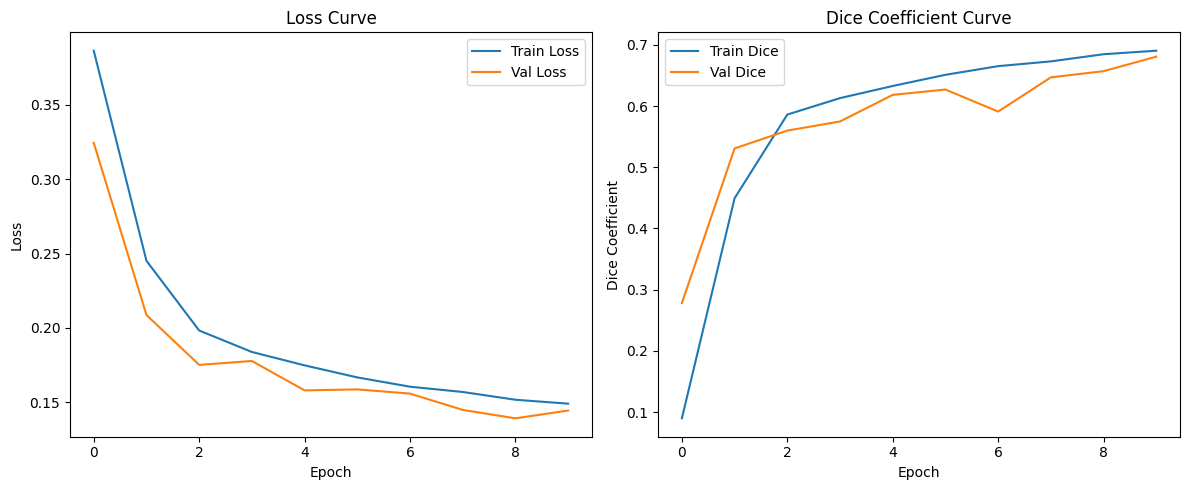

In [15]:
# Plotting loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plotting dice coefficient curves
plt.subplot(1, 2, 2)
plt.plot(train_dices, label='Train Dice')
plt.plot(val_dices, label='Val Dice')
plt.title("Dice Coefficient Curve")
plt.xlabel("Epoch")
plt.ylabel("Dice Coefficient")
plt.legend()

plt.tight_layout()
plt.show()

Test Dice Coefficient: 0.1418


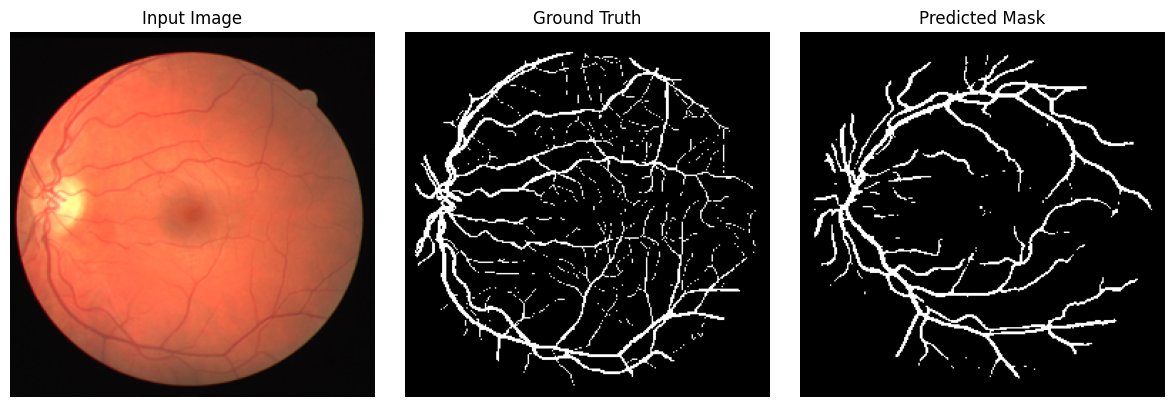

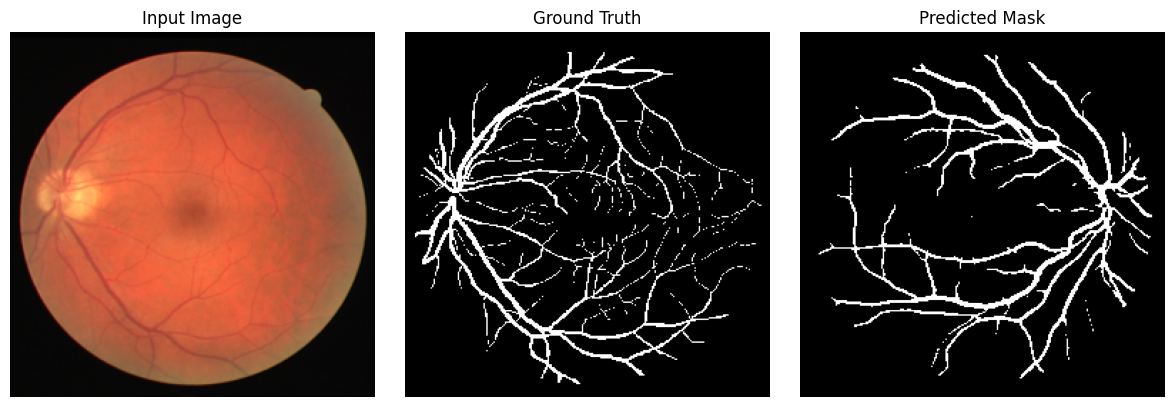

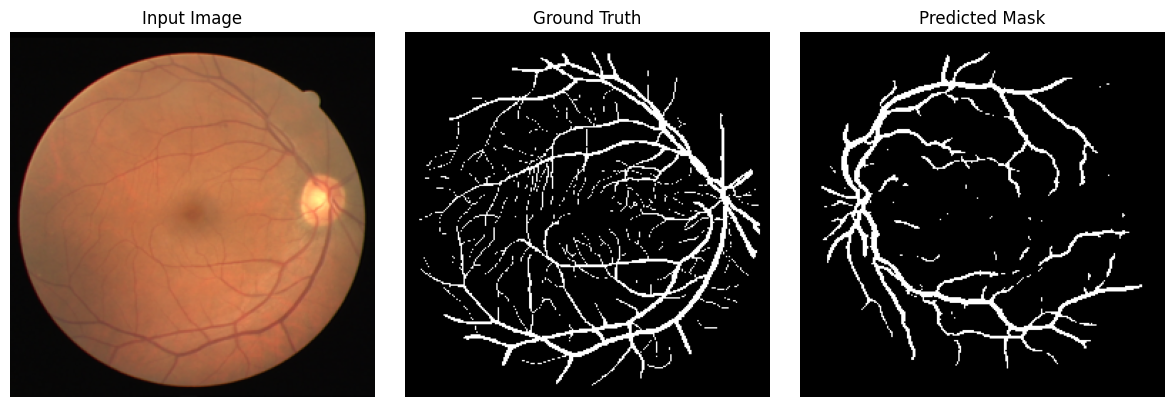

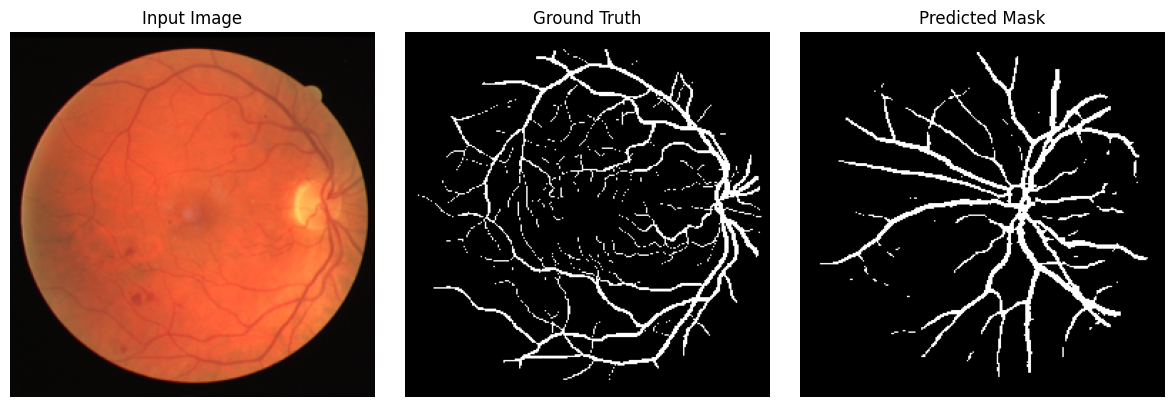

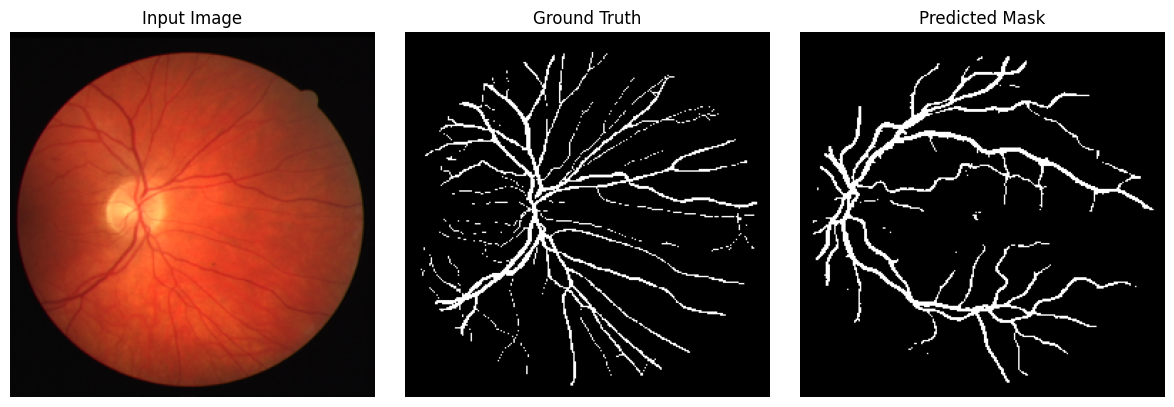

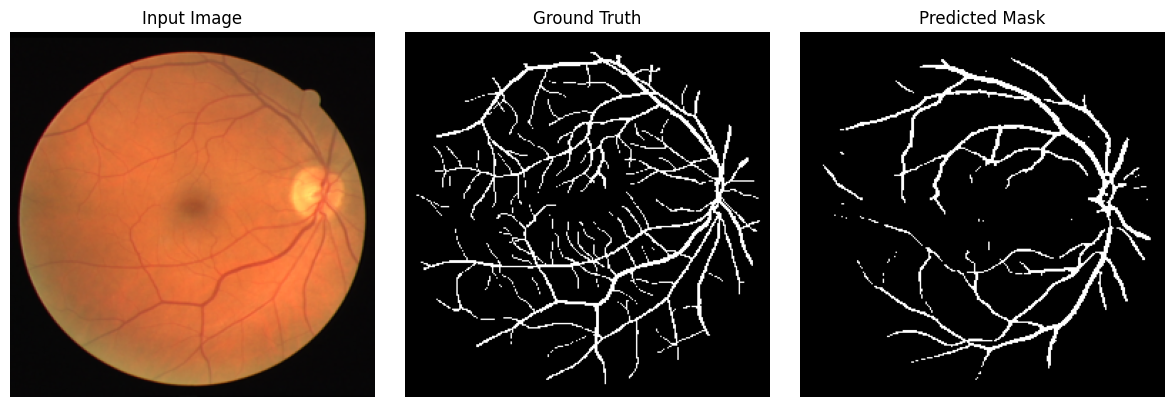

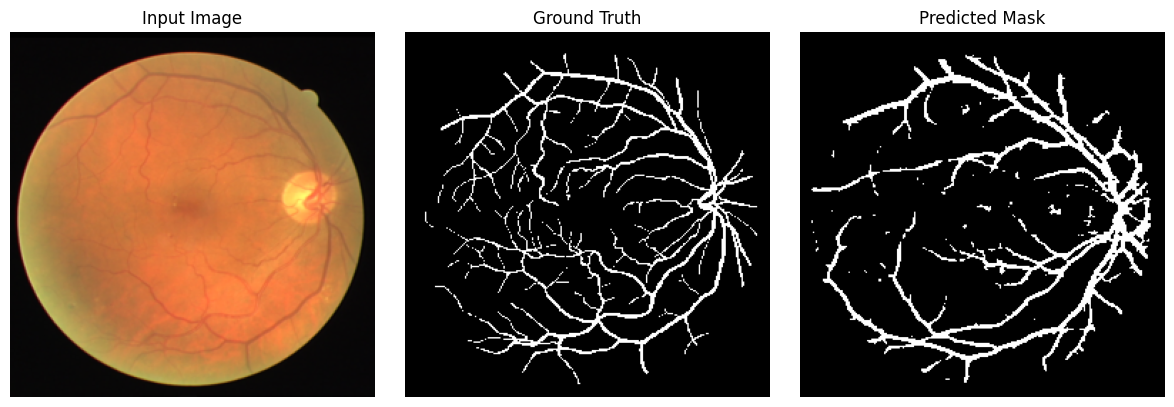

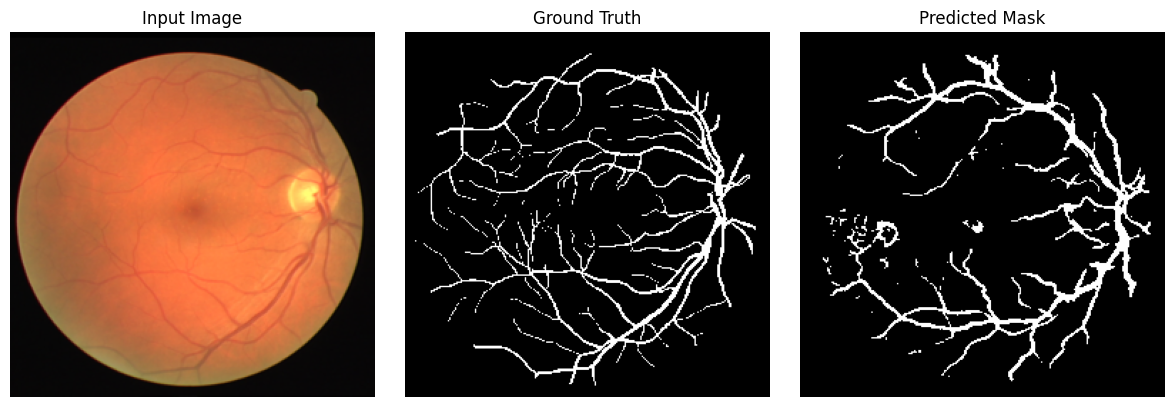

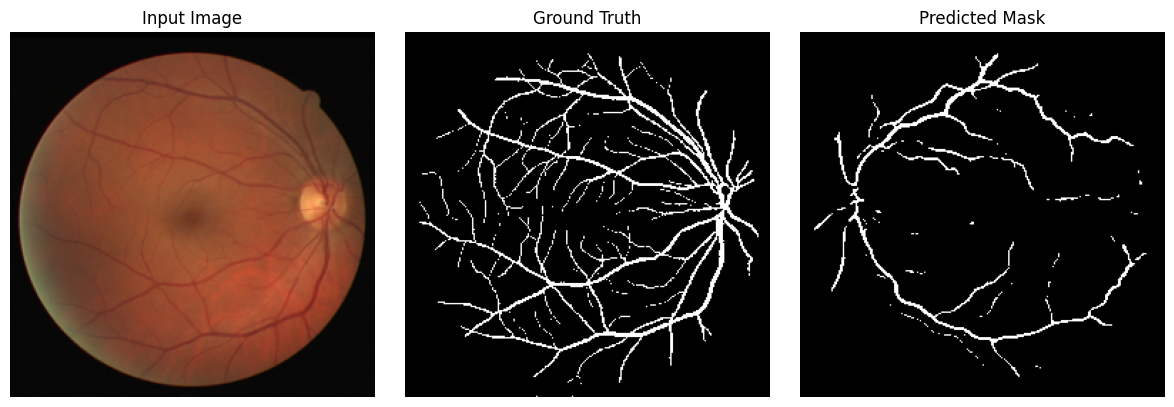

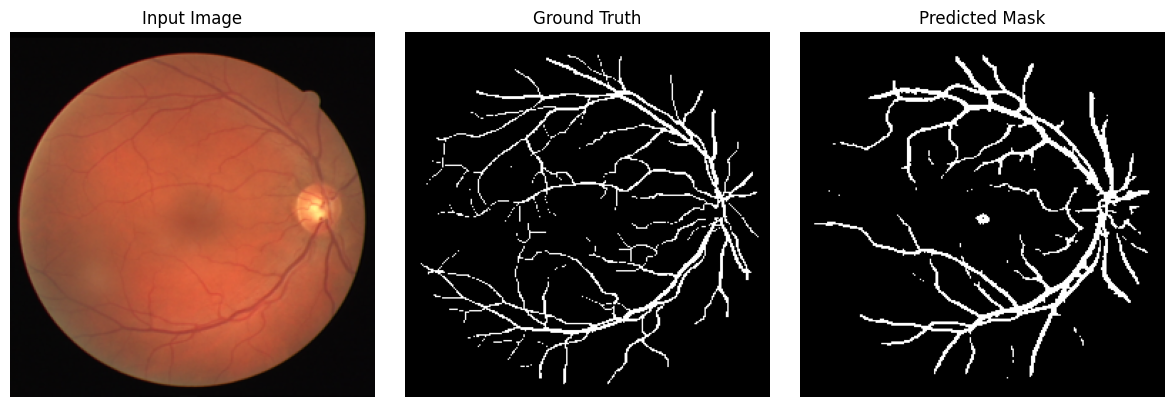

In [16]:
model.eval()
test_dice = 0.0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        preds = output
        preds = (preds > 0.5).float()

        test_dice = dice_coef(preds, masks)
        print(f"Test Dice Coefficient: {test_dice:.4f}")

        for i in range(images.size(0)):
            img = images[i].cpu().permute(1, 2, 0).numpy()
            img = (img * 0.5) + 0.5  

            mask = masks[i].cpu().squeeze().numpy()
            pred = preds[i].cpu().squeeze().numpy()

            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1)
            plt.imshow(img)
            plt.title('Input Image')
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(mask, cmap='gray')
            plt.title('Ground Truth')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(pred, cmap='gray')
            plt.title('Predicted Mask')
            plt.axis('off')

            plt.tight_layout()
            plt.show()
